In [2]:
library(DESeq2)

Loading required package: S4Vectors

Loading required package: stats4

Loading required package: BiocGenerics


Attaching package: ‘BiocGenerics’


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, intersect, is.unsorted, lapply, Map, mapply,
    match, mget, order, paste, pmax, pmax.int, pmin, pmin.int,
    Position, rank, rbind, Reduce, rownames, sapply, saveRDS, setdiff,
    table, tapply, union, unique, unsplit, which.max, which.min



Attaching package: ‘S4Vectors’


The following object is masked from ‘package:utils’:

    findMatches


The following objects are masked from ‘package:base’:

    expand.grid, I, unname


Loading required package: IRanges

Loading required package: GenomicRanges

Loading required package: GenomeInfoDb



In [3]:
counts <- read.csv(
  "/scratch/user/s4575250/BIOX7014_Thesis/write/04_DEG/PICA_Batch001-Batch007/CD8_pseudobulk_counts_gene_by_sample.csv",
  row.names = 1,
  check.names = FALSE
)

meta <- read.csv(
  "/scratch/user/s4575250/BIOX7014_Thesis/write/04_DEG/PICA_Batch001-Batch007/CD8_pseudobulk_metadata.csv",
  row.names = 1,
  check.names = FALSE
)

In [4]:
# match sample order
meta <- meta[colnames(counts), ]

stopifnot(all(colnames(counts) == rownames(meta)))

In [5]:
meta$age <- as.numeric(meta$age)
meta$sex <- factor(meta$sex)
meta$batch <- factor(meta$batch)
meta$cell_type <- factor(meta$cell_type)

# quick check
table(meta$cell_type)
summary(meta$age)
table(meta$sex)
table(meta$batch)


CD8 GZMK+ naive/Tcm       CD8 naive/Tcm             CD8 Tem 
                128                 128                 121 

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   0.05    4.43    7.51    8.28   12.84   17.03 


Female   Male 
   156    221 


20240530_WGS_20240530_sc_PICA0001-PICA0007 
                                        19 
20240918_WGS_20240924_sc_PICA0008-PICA0032 
                                        65 
20241106_WGS_20241106_sc_PICA0033-PICA0069 
                                        71 
20250114_WGS_20241218_sc_PICA0071-PICA0097 
                                        71 
20250324_WGS_20250324_sc_PICA0098-PICA0118 
                                        45 
20250612_WGS_20250612_sc_PICA0119-PICA0146 
                                        63 
20250814_WGS_20250814_sc_PICA0147-PICA0173 
                                        43 

## DESeq2

In [6]:
dir.create("/scratch/user/s4575250/BIOX7014_Thesis/Results/PICA_Batch001-Batch007/04_DEG/CD8", showWarnings = FALSE)

run_deseq_celltype <- function(ct) {
  
  samples <- rownames(meta)[meta$cell_type == ct]
  
  counts_sub <- counts[, samples, drop = FALSE]
  meta_sub <- meta[samples, , drop = FALSE]
  
  # skip if too few donor samples
  if (ncol(counts_sub) < 6) {
    message("Skipping ", ct, ": too few samples")
    return(NULL)
  }
  
  # filter lowly expressed genes
  keep_genes <- rowSums(counts_sub >= 10) >= 3
  counts_sub <- counts_sub[keep_genes, ]
  
  dds <- DESeqDataSetFromMatrix(
    countData = round(as.matrix(counts_sub)),
    colData = meta_sub,
    design = ~ batch + sex + age
  )
  
  dds <- DESeq(dds)
  
  res <- results(dds, name = "age")
  res <- as.data.frame(res)
  res$gene <- rownames(res)
  res <- res[order(res$padj), ]
  
  safe_ct <- gsub("[ /+]", "_", ct)
  
  write.csv(
    res,
    paste0("/scratch/user/s4575250/BIOX7014_Thesis/Results/PICA_Batch001-Batch007/04_DEG/CD8/DESeq2_age_", safe_ct, ".csv"),
    row.names = FALSE
  )
  
  sig <- res[!is.na(res$padj) & res$padj < 0.05, ]
  
  write.csv(
    sig,
    paste0("/scratch/user/s4575250/BIOX7014_Thesis/Results/PICA_Batch001-Batch007/04_DEG/CD8/DESeq2_age_", safe_ct, "_significant.csv"),
    row.names = FALSE
  )
  
  return(res)
}

celltypes <- levels(meta$cell_type)

all_deg <- list()

for (ct in celltypes) {
  all_deg[[ct]] <- run_deseq_celltype(ct)
}

converting counts to integer mode

  the design formula contains one or more numeric variables that have mean or
  standard deviation larger than 5 (an arbitrary threshold to trigger this message).
  Including numeric variables with large mean can induce collinearity with the intercept.
  Users should center and scale numeric variables in the design to improve GLM convergence.

  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]

estimating size factors

  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an 

In [7]:
# summary table
summary_list <- list()

for (ct in names(all_deg)) {
  
  res <- all_deg[[ct]]
  
  if (is.null(res)) {
    summary_list[[ct]] <- data.frame(
      cell_type = ct,
      n_sig = NA,
      n_up_with_age = NA,
      n_down_with_age = NA
    )
  } else {
    sig <- res[!is.na(res$padj) & res$padj < 0.05, ]
    
    summary_list[[ct]] <- data.frame(
      cell_type = ct,
      n_sig = nrow(sig),
      n_up_with_age = sum(sig$log2FoldChange > 0),
      n_down_with_age = sum(sig$log2FoldChange < 0)
    )
  }
}

deg_summary <- do.call(rbind, summary_list)

write.csv(
  deg_summary,
  "/scratch/user/s4575250/BIOX7014_Thesis/Results/PICA_Batch001-Batch007/04_DEG/CD8/DESeq2_age_summary.csv",
  row.names = FALSE
)

deg_summary

,cell_type,n_sig,n_up_with_age,n_down_with_age
,<chr>,<int>,<int>,<int>
CD8 GZMK+ naive/Tcm,CD8 GZMK+ naive/Tcm,3853,2213,1640
CD8 naive/Tcm,CD8 naive/Tcm,6933,3615,3318
CD8 Tem,CD8 Tem,1597,929,668


In [8]:
dir.create("/scratch/user/s4575250/BIOX7014_Thesis/Results/PICA_Batch001-Batch007/04_DEG/CD8/top_genes", showWarnings = FALSE, recursive = TRUE)
dir.create("/scratch/user/s4575250/BIOX7014_Thesis/Results/PICA_Batch001-Batch007/04_DEG/CD8/volcano_plots", showWarnings = FALSE, recursive = TRUE)
dir.create("/scratch/user/s4575250/BIOX7014_Thesis/Results/PICA_Batch001-Batch007/04_DEG/CD8/heatmaps", showWarnings = FALSE, recursive = TRUE)

In [9]:
# top degs
for (ct in names(all_deg)) {
  
  res <- all_deg[[ct]]
  
  if (is.null(res)) next
  
  res <- res[!is.na(res$padj), ]
  res <- res[order(res$padj), ]
  
  top20 <- head(res, 20)
  
  safe_ct <- gsub("[ /+]", "_", ct)
  
  write.csv(
    top20,
    paste0("/scratch/user/s4575250/BIOX7014_Thesis/Results/PICA_Batch001-Batch007/04_DEG/CD8/top_genes/top20_DEGs_", safe_ct, ".csv"),
    row.names = FALSE
  )
}

# View top genes for key subsets
head(all_deg[["CD8 GZMK+ naive/Tcm"]][order(all_deg[["CD8 GZMK+ naive/Tcm"]]$padj), ], 20)
head(all_deg[["CD8 Tem"]][order(all_deg[["CD8 Tem"]]$padj), ], 20)
head(all_deg[["CD8 naive/Tcm"]][order(all_deg[["CD8 naive/Tcm"]]$padj), ], 20)

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,gene
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
TPRG1,41.439644,0.16715422,0.010833497,15.42939,1.038502e-53,1.451722e-49,TPRG1
PLCB1,115.865986,0.17522756,0.011503621,15.23238,2.155864e-52,1.506841e-48,PLCB1
MID2,13.904020,0.21269619,0.014833965,14.33846,1.258187e-46,5.862733e-43,MID2
CPQ,102.705028,0.10648887,0.007739061,13.75992,4.440143e-43,1.551719e-39,CPQ
RADX,26.953721,0.14162305,0.010433045,13.57447,5.675265e-42,1.586691e-38,RADX
CYB561,44.624062,0.12590058,0.009368660,13.43848,3.597356e-41,8.381241e-38,CYB561
MYBL1,227.747167,0.14756481,0.011348123,13.00345,1.169387e-38,2.335266e-35,MYBL1
ZSWIM5,22.357429,0.14330393,0.011046119,12.97324,1.735419e-38,3.032427e-35,ZSWIM5
NFIA,41.685239,0.10622828,0.008425252,12.60832,1.899970e-36,2.951076e-33,NFIA


,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,gene
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
NR3C2,29.366337,0.21017602,0.019843529,10.591666,3.257433e-26,3.174633e-22,NR3C2
CASP4LP,42.332437,0.09661497,0.009145413,10.564310,4.361659e-26,3.174633e-22,CASP4LP
TPRG1,46.620009,0.07714597,0.007722872,9.989285,1.698024e-23,8.239380e-20,TPRG1
CFH,2.662113,0.41371240,0.043558275,9.497906,2.141533e-21,7.793574e-18,CFH
PLCB1,186.947944,0.13073709,0.013912514,9.397086,5.609510e-21,1.633153e-17,PLCB1
AKT3,192.950235,0.12821104,0.014387460,8.911305,5.043536e-19,1.223646e-15,AKT3
VIM,1156.727338,0.05283832,0.006057590,8.722664,2.717324e-18,5.650869e-15,VIM
CPQ,118.930466,0.07537819,0.008764480,8.600418,7.942608e-18,1.351499e-14,CPQ
TMOD2,14.591319,0.12430575,0.014463243,8.594597,8.355767e-18,1.351499e-14,TMOD2


,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,gene
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
DISC1FP1,70.414812,0.24606090,0.013474531,18.26118,1.685938e-74,2.910267e-70,DISC1FP1
TOX-DT,65.541764,-0.13738985,0.008859817,-15.50708,3.107136e-54,2.681769e-50,TOX-DT
LINC01684,78.725678,0.18519615,0.012212958,15.16391,6.131181e-52,3.527881e-48,LINC01684
LONRF3,25.268986,0.23716136,0.016066081,14.76162,2.589915e-49,1.117678e-45,LONRF3
EPHA4,140.746636,-0.20680039,0.014311325,-14.45012,2.502433e-47,8.639399e-44,EPHA4
BEX5,48.328174,0.22493793,0.016067178,13.99984,1.562220e-44,4.494506e-41,BEX5
CDCA7,34.721572,-0.21646669,0.016126778,-13.42281,4.445268e-41,1.096203e-37,CDCA7
TCEAL2,3.320941,0.43135552,0.032186095,13.40192,5.891774e-41,1.271298e-37,TCEAL2
MYO6,10.075007,0.21031891,0.015817937,13.29623,2.434382e-40,4.669145e-37,MYO6


In [10]:
# Combined top DEG table
combined_top_list <- list()

for (ct in names(all_deg)) {
  
  res <- all_deg[[ct]]
  
  if (is.null(res)) next
  
  res <- res[!is.na(res$padj), ]
  res <- res[order(res$padj), ]
  
  top20 <- head(res, 20)
  top20$cell_type <- ct
  
  combined_top_list[[ct]] <- top20
}

combined_top_degs <- do.call(rbind, combined_top_list)

write.csv(
  combined_top_degs,
  "/scratch/user/s4575250/BIOX7014_Thesis/Results/PICA_Batch001-Batch007/04_DEG/CD8/CD8_combined_top20_DEGs_by_celltype.csv",
  row.names = FALSE
)

combined_top_degs

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,gene,cell_type
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
CD8 GZMK+ naive/Tcm.TPRG1,41.439644,0.16715422,0.010833497,15.429388,1.038502e-53,1.451722e-49,TPRG1,CD8 GZMK+ naive/Tcm
CD8 GZMK+ naive/Tcm.PLCB1,115.865986,0.17522756,0.011503621,15.232384,2.155864e-52,1.506841e-48,PLCB1,CD8 GZMK+ naive/Tcm
CD8 GZMK+ naive/Tcm.MID2,13.904020,0.21269619,0.014833965,14.338459,1.258187e-46,5.862733e-43,MID2,CD8 GZMK+ naive/Tcm
CD8 GZMK+ naive/Tcm.CPQ,102.705028,0.10648887,0.007739061,13.759921,4.440143e-43,1.551719e-39,CPQ,CD8 GZMK+ naive/Tcm
CD8 GZMK+ naive/Tcm.RADX,26.953721,0.14162305,0.010433045,13.574470,5.675265e-42,1.586691e-38,RADX,CD8 GZMK+ naive/Tcm
CD8 GZMK+ naive/Tcm.CYB561,44.624062,0.12590058,0.009368660,13.438483,3.597356e-41,8.381241e-38,CYB561,CD8 GZMK+ naive/Tcm
CD8 GZMK+ naive/Tcm.MYBL1,227.747167,0.14756481,0.011348123,13.003455,1.169387e-38,2.335266e-35,MYBL1,CD8 GZMK+ naive/Tcm
CD8 GZMK+ naive/Tcm.ZSWIM5,22.357429,0.14330393,0.011046119,12.973238,1.735419e-38,3.032427e-35,ZSWIM5,CD8 GZMK+ naive/Tcm
CD8 GZMK+ naive/Tcm.NFIA,41.685239,0.10622828,0.008425252,12.608321,1.899970e-36,2.951076e-33,NFIA,CD8 GZMK+ naive/Tcm


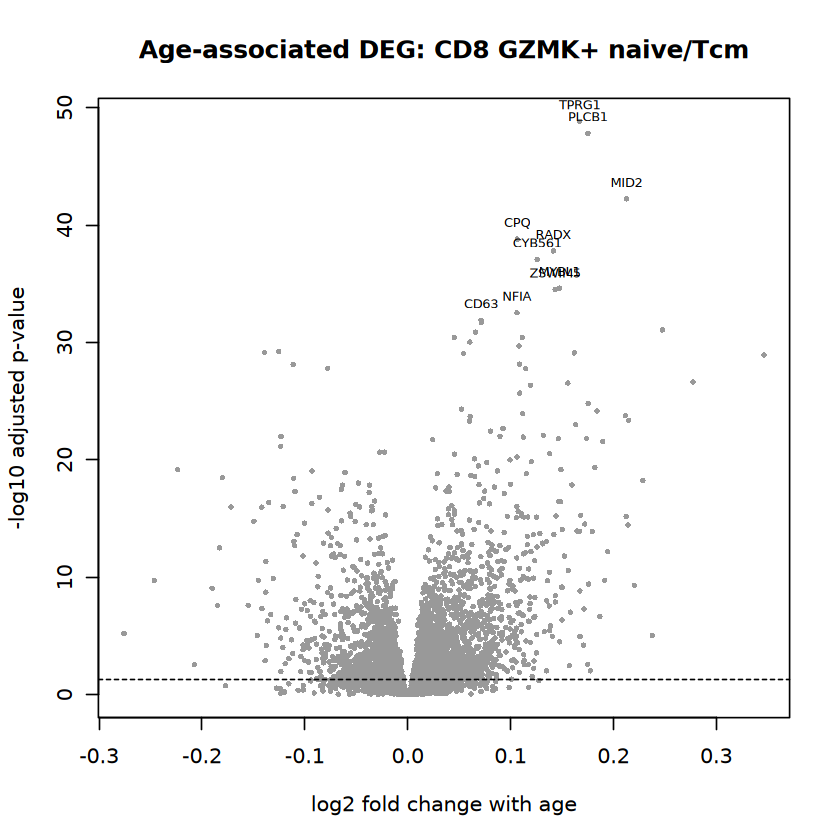

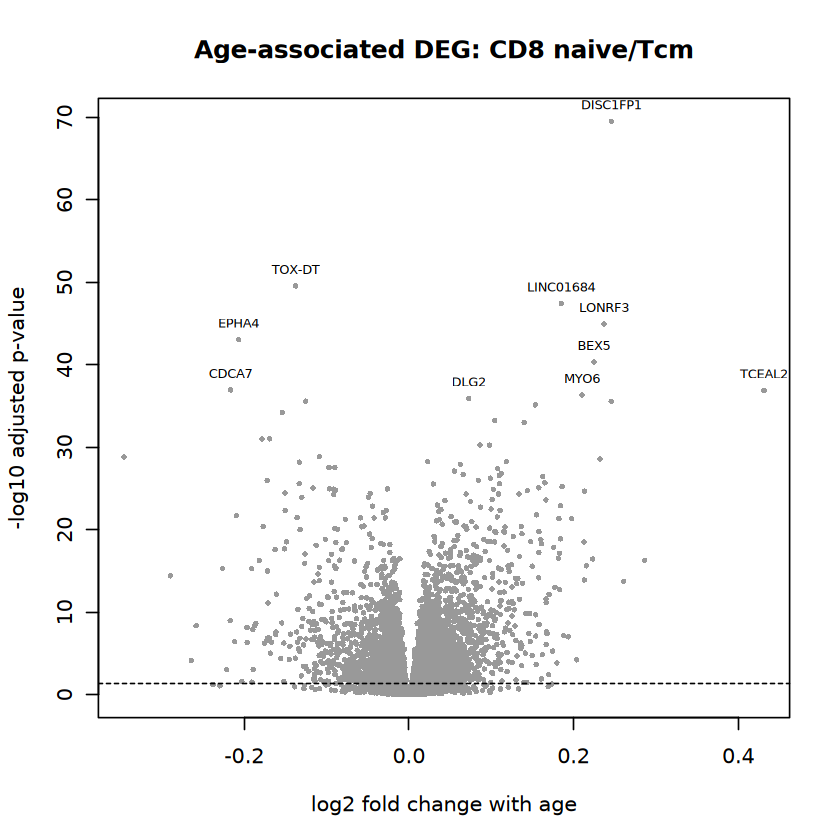

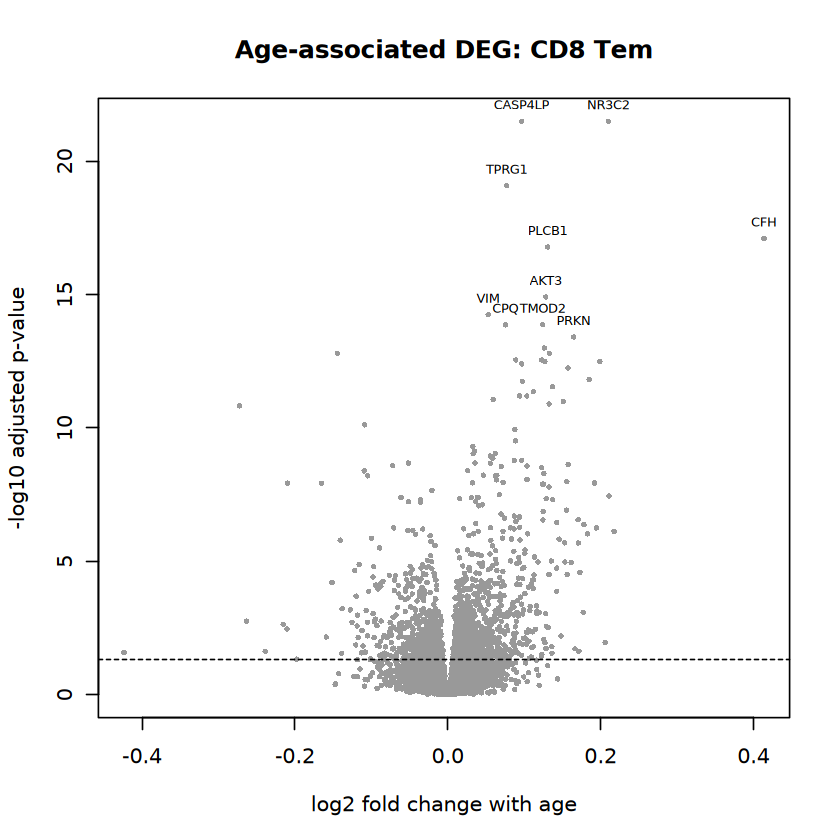

In [11]:
# Volcano plot
plot_volcano <- function(res, celltype_name, padj_cutoff = 0.05, lfc_cutoff = 0.5, save_plot = TRUE) {
  
  res <- res[!is.na(res$padj), ]
  
  res$neg_log10_padj <- -log10(res$padj)
  res$significant <- res$padj < padj_cutoff & abs(res$log2FoldChange) > lfc_cutoff
  
  top_genes <- head(res[order(res$padj), ], 10)
  
  # Display in notebook
  plot(
    res$log2FoldChange,
    res$neg_log10_padj,
    pch = 16,
    cex = 0.5,
    col = ifelse(res$significant, "red", "grey60"),
    xlab = "log2 fold change with age",
    ylab = "-log10 adjusted p-value",
    main = paste("Age-associated DEG:", celltype_name)
  )
  
  abline(v = c(-lfc_cutoff, lfc_cutoff), lty = 2, col = "black")
  abline(h = -log10(padj_cutoff), lty = 2, col = "black")
  
  text(
    top_genes$log2FoldChange,
    top_genes$neg_log10_padj,
    labels = top_genes$gene,
    pos = 3,
    cex = 0.6
  )
  
  # Save PNG
  if (save_plot) {
    
    safe_ct <- gsub("[ /+]", "_", celltype_name)
    
    png(
      paste0("/scratch/user/s4575250/BIOX7014_Thesis/Results/PICA_Batch001-Batch007/04_DEG/CD8/volcano_plots/volcano_", safe_ct, ".png"),
      width = 1800,
      height = 1500,
      res = 200
    )
    
    plot(
      res$log2FoldChange,
      res$neg_log10_padj,
      pch = 16,
      cex = 0.5,
      col = ifelse(res$significant, "red", "grey60"),
      xlab = "log2 fold change with age",
      ylab = "-log10 adjusted p-value",
      main = paste("Age-associated DEG:", celltype_name)
    )
    
    abline(v = c(-lfc_cutoff, lfc_cutoff), lty = 2, col = "black")
    abline(h = -log10(padj_cutoff), lty = 2, col = "black")
    
    text(
      top_genes$log2FoldChange,
      top_genes$neg_log10_padj,
      labels = top_genes$gene,
      pos = 3,
      cex = 0.6
    )
    
    dev.off()
  }
}

for (ct in names(all_deg)) {
  
  res <- all_deg[[ct]]
  
  if (is.null(res)) next
  
  plot_volcano(res, ct)
}

Making heatmap for: CD8 GZMK+ naive/Tcm



converting counts to integer mode

  the design formula contains one or more numeric variables that have mean or
  standard deviation larger than 5 (an arbitrary threshold to trigger this message).
  Including numeric variables with large mean can induce collinearity with the intercept.
  Users should center and scale numeric variables in the design to improve GLM convergence.

  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]

Making heatmap for: CD8 naive/Tcm

converting counts to integer mode

  the design formula contains one or more numeric variables that have mean or
  standard deviation larger than 5 (an arbitrary threshold to trigger this message).
  Including numeric variables with large mean can induce collinearity with the interc

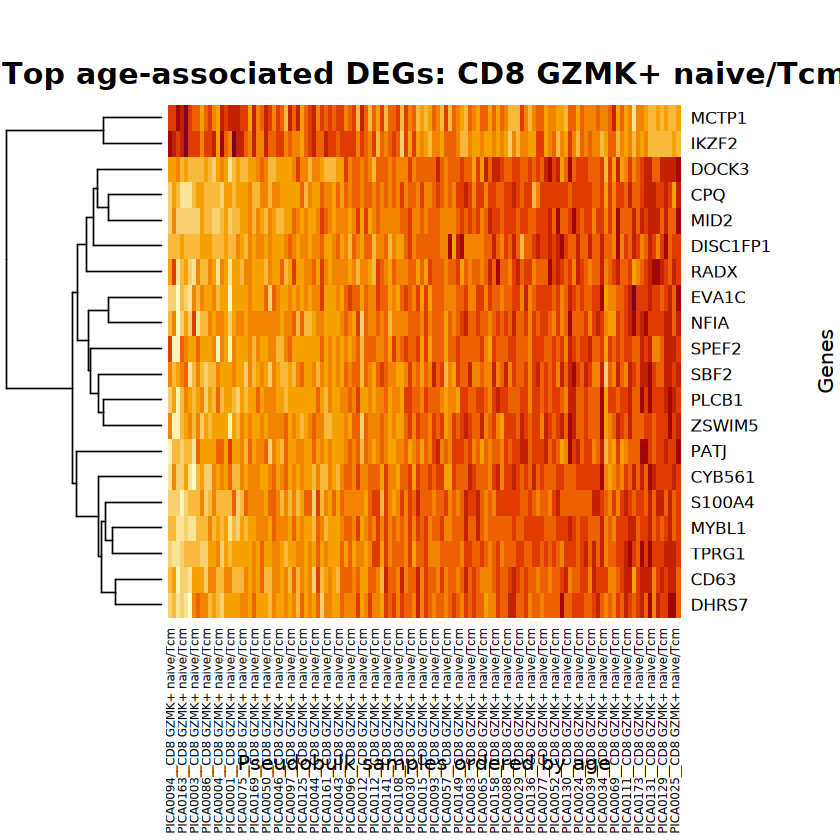

Making heatmap for: CD8 Tem

converting counts to integer mode

  the design formula contains one or more numeric variables that have mean or
  standard deviation larger than 5 (an arbitrary threshold to trigger this message).
  Including numeric variables with large mean can induce collinearity with the intercept.
  Users should center and scale numeric variables in the design to improve GLM convergence.

  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]



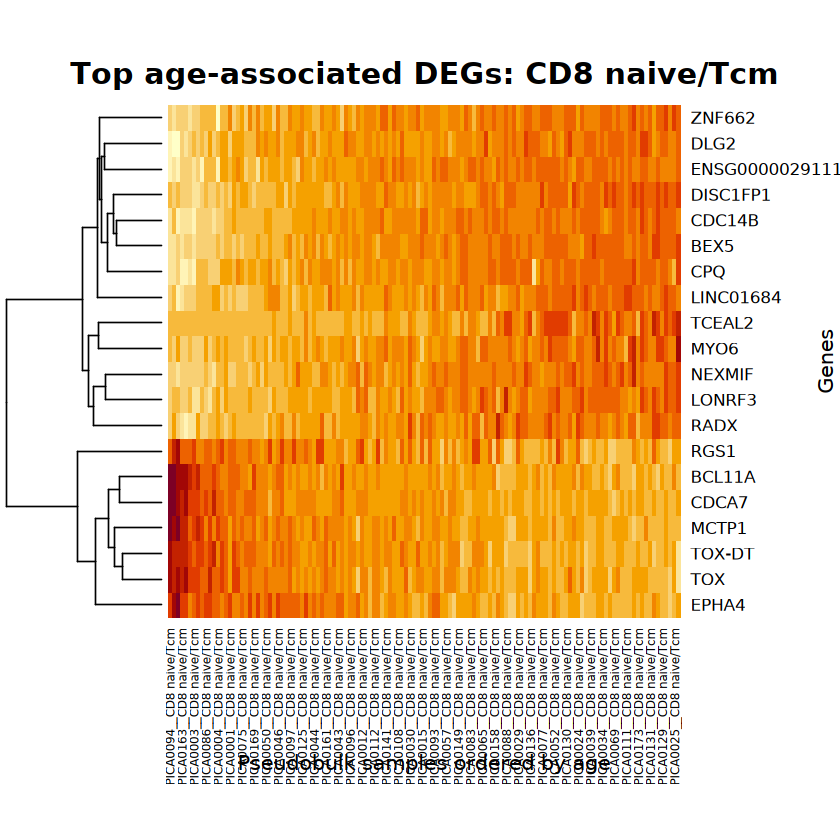

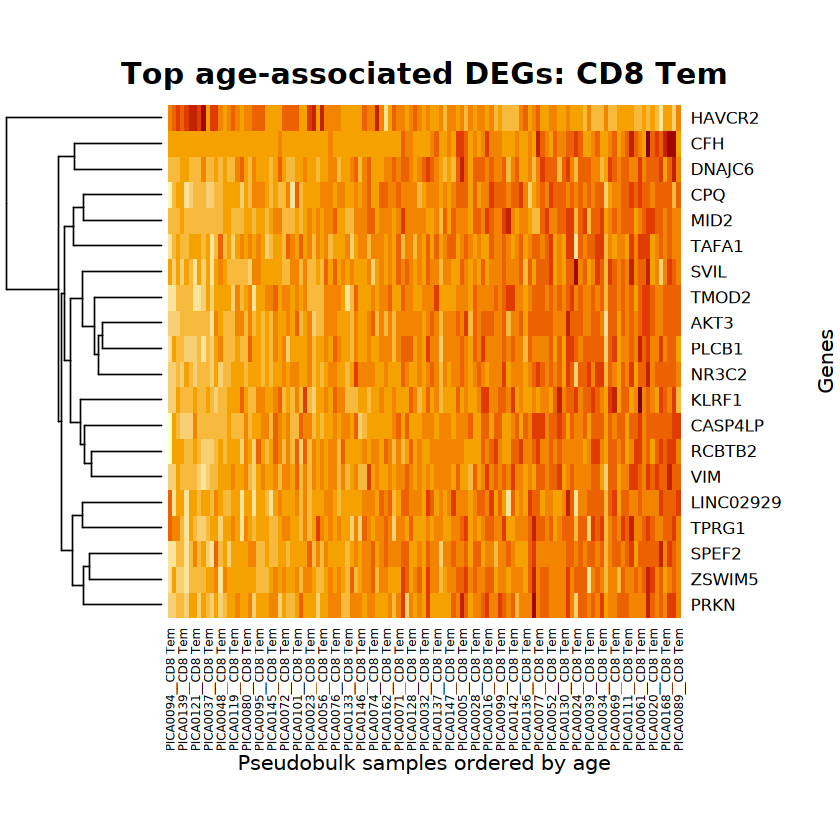

In [12]:
# heatmap of top genes
make_heatmap <- function(ct, top_n = 20, save_plot = TRUE) {
  
  message("Making heatmap for: ", ct)
  
  res <- all_deg[[ct]]
  
  if (is.null(res)) {
    message("No DEG result for: ", ct)
    return(NULL)
  }
  
  res <- res[!is.na(res$padj), ]
  res <- res[order(res$padj), ]
  
  top_genes <- head(res$gene, top_n)
  
  samples <- rownames(meta)[meta$cell_type == ct]
  
  counts_sub <- counts[, samples, drop = FALSE]
  meta_sub <- meta[samples, , drop = FALSE]
  
  keep_genes <- rowSums(counts_sub >= 10) >= 3
  counts_sub <- counts_sub[keep_genes, ]
  
  top_genes <- top_genes[top_genes %in% rownames(counts_sub)]
  
  if (length(top_genes) < 2) {
    message("Too few top genes available for heatmap: ", ct)
    return(NULL)
  }
  
  dds <- DESeqDataSetFromMatrix(
    countData = round(as.matrix(counts_sub)),
    colData = meta_sub,
    design = ~ batch + sex + age
  )
  
  vsd <- vst(dds, blind = TRUE)
  
  mat <- assay(vsd)[top_genes, , drop = FALSE]
  
  # z-score per gene
  mat_scaled <- t(scale(t(mat)))
  
  # order samples by age
  sample_order <- order(meta_sub$age)
  mat_scaled <- mat_scaled[, sample_order, drop = FALSE]
  
  # Display in notebook
  heatmap(
    mat_scaled,
    Colv = NA,
    scale = "none",
    margins = c(8, 8),
    main = paste("Top age-associated DEGs:", ct),
    xlab = "Pseudobulk samples ordered by age",
    ylab = "Genes"
  )
  
  # Save PNG
  if (save_plot) {
    
    safe_ct <- gsub("[ /+]", "_", ct)
    
    png(
      paste0("/scratch/user/s4575250/BIOX7014_Thesis/Results/PICA_Batch001-Batch007/04_DEG/CD8/heatmaps/heatmap_top", top_n, "_", safe_ct, ".png"),
      width = 2000,
      height = 1600,
      res = 200
    )
    
    heatmap(
      mat_scaled,
      Colv = NA,
      scale = "none",
      margins = c(8, 8),
      main = paste("Top age-associated DEGs:", ct),
      xlab = "Pseudobulk samples ordered by age",
      ylab = "Genes"
    )
    
    dev.off()
  }
}


for (ct in names(all_deg)) {
  make_heatmap(ct, top_n = 20)
}

In [14]:
# biological check
marker_genes <- c(
  # Naive / central memory
  "CCR7", "SELL", "IL7R", "LTB", "TCF7",

  # Cytotoxic / effector
  "NKG7", "PRF1", "GZMB", "GZMK", "GNLY", "CTSW",

  # Terminal / effector differentiation
  "CX3CR1", "FGFBP2", "ZEB2",

  # Activation / exhaustion
  "PDCD1", "LAG3", "TIGIT", "HAVCR2", "TOX",

  # Interferon response
  "ISG15", "IFIT1", "IFIT3", "MX1",

  # Proliferation
  "MKI67", "TOP2A"        
)

marker_summary_list <- list()

for (ct in names(all_deg)) {
  
  res <- all_deg[[ct]]
  
  if (is.null(res)) next
  
  sub <- res[res$gene %in% marker_genes, ]
  sub$cell_type <- ct
  
  marker_summary_list[[ct]] <- sub
}

marker_summary <- do.call(rbind, marker_summary_list)

write.csv(
  marker_summary,
  "/scratch/user/s4575250/BIOX7014_Thesis/Results/PICA_Batch001-Batch007/04_DEG/CD8/CD8_marker_gene_DEG_summary.csv",
  row.names = FALSE
)

marker_summary

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,gene,cell_type
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
CD8 GZMK+ naive/Tcm.SELL,1278.749933,-4.938859e-02,0.006848496,-7.211597163,5.529937e-13,2.863074e-11,SELL,CD8 GZMK+ naive/Tcm
CD8 GZMK+ naive/Tcm.TCF7,1230.392719,-3.017449e-02,0.004322345,-6.981045710,2.929910e-12,1.321200e-10,TCF7,CD8 GZMK+ naive/Tcm
CD8 GZMK+ naive/Tcm.CCR7,481.847735,-5.178438e-02,0.007489101,-6.914633048,4.690760e-12,2.023831e-10,CCR7,CD8 GZMK+ naive/Tcm
CD8 GZMK+ naive/Tcm.LAG3,114.018023,5.119102e-02,0.007888119,6.489635199,8.604446e-11,2.969915e-09,LAG3,CD8 GZMK+ naive/Tcm
CD8 GZMK+ naive/Tcm.IL7R,2296.013387,4.567378e-02,0.007525188,6.069454033,1.283458e-09,3.456929e-08,IL7R,CD8 GZMK+ naive/Tcm
CD8 GZMK+ naive/Tcm.ISG15,265.735142,-5.614811e-02,0.009557735,-5.874624932,4.238018e-09,1.021435e-07,ISG15,CD8 GZMK+ naive/Tcm
CD8 GZMK+ naive/Tcm.GNLY,1272.230747,1.017982e-01,0.020357902,5.000427286,5.720340e-07,8.654181e-06,GNLY,CD8 GZMK+ naive/Tcm
CD8 GZMK+ naive/Tcm.TOX,306.466329,-3.682585e-02,0.008000768,-4.602789967,4.168686e-06,5.143341e-05,TOX,CD8 GZMK+ naive/Tcm
CD8 GZMK+ naive/Tcm.MKI67,16.439692,-9.597818e-02,0.021623461,-4.438613231,9.054035e-06,1.028995e-04,MKI67,CD8 GZMK+ naive/Tcm
